In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.base import clone

In [2]:
DATA_PATH = "../../data/pr_review_traces/processed/final_security_patch.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 29)


,repo_name,pr_number,pr_title,pr_body,pr_state,pr_created_at,pr_updated_at,pr_merged_at,pr_merge_commit_sha,pr_additions,...,line,original_line,side,start_line,original_start_line,author_association,comment_created_at,comment_updated_at,security_label,label_notes
0,grommet/hpe-design-system,5159,add datafilters wcag,<!--- Provide a general summary of the PR in t...,closed,2025-05-13T05:06:52Z,2025-05-20T00:28:06Z,2025-05-20T00:28:06Z,ed2105adad46b12a9272c15d35f3aaee6a47026b,1040,...,NaN,6,RIGHT,NaN,NaN,COLLABORATOR,2025-05-15T18:22:15Z,2025-05-15T18:22:15Z,0,No security-relevant topic found in the commen...
1,appsmithorg/appsmith,39646,feat: implement table widget infinite scroll w...,## Description\r\nThis PR adds support for var...,closed,2025-03-10T08:00:48Z,2025-03-21T10:14:18Z,2025-03-20T09:23:37Z,c162311f43efe652627cdf1b950d7eb7419043e8,594,...,NaN,55,RIGHT,NaN,38.0,CONTRIBUTOR,2025-03-19T05:22:40Z,2025-03-19T05:28:15Z,1,Labeled 1: comment/diff references a security-...
2,adorsys/status-list-server,55,feat: add keypair generation to startup logic,NaN,closed,2025-04-24T12:13:50Z,2025-05-23T09:31:36Z,2025-05-23T09:31:33Z,35084ed00253b0d082124e96014502a4f340667b,351,...,NaN,99,RIGHT,NaN,NaN,COLLABORATOR,2025-05-05T15:48:29Z,2025-05-05T16:15:35Z,1,Labeled 1: comment/diff contains a clear secur...
3,vinteumorg/Floresta,402,Re-structured functional tests.,Improves https://github.com/vinteumorg/Florest...,closed,2025-03-07T14:34:25Z,2025-03-12T16:19:02Z,2025-03-12T16:19:02Z,443bf8defd0b7a370d267e6253ec2d4291a496bb,447,...,330.0,330,RIGHT,NaN,NaN,MEMBER,2025-03-10T15:48:21Z,2025-03-10T15:48:21Z,1,Labeled 1: comment/diff contains a clear secur...
4,vacanza/holidays,2502,Update India holidays: add missing Tamil Nadu ...,<!--\r\n Thanks for contributing to holidays!...,closed,2025-04-26T14:04:29Z,2025-05-05T18:10:53Z,2025-04-28T20:20:40Z,5f154404cac9bee763b2cbafa2e9e15ef993741c,155,...,905.0,905,RIGHT,869.0,869.0,CONTRIBUTOR,2025-04-26T16:36:43Z,2025-04-26T16:36:44Z,0,No security-relevant topic found in the commen...


In [3]:
print("Columns:")
for column in df.columns:
    print("-", column)

Columns:
- repo_name
- pr_number
- pr_title
- pr_body
- pr_state
- pr_created_at
- pr_updated_at
- pr_merged_at
- pr_merge_commit_sha
- pr_additions
- pr_deletions
- pr_changed_files
- comment_id
- review_id
- review_comment
- diff_hunk
- file_path
- commit_id
- original_commit_id
- line
- original_line
- side
- start_line
- original_start_line
- author_association
- comment_created_at
- comment_updated_at
- security_label
- label_notes


In [4]:
print("Original label distribution:")
print(df["security_label"].value_counts().sort_index())

print("\nOriginal label percentages:")
print(
    (df["security_label"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

Original label distribution:
security_label
0    2930
1    1073
2     997
Name: count, dtype: int64

Original label percentages:
security_label
0    58.60
1    21.46
2    19.94
Name: proportion, dtype: float64


In [5]:
df_binary = df[df["security_label"].isin([0, 1])].copy()

df_binary["security_label"] = df_binary["security_label"].astype(int)

print("Binary dataset shape:", df_binary.shape)

print("\nBinary label distribution:")
print(df_binary["security_label"].value_counts().sort_index())

Binary dataset shape: (4003, 29)

Binary label distribution:
security_label
0    2930
1    1073
Name: count, dtype: int64


In [6]:
print("Missing review comments:", df_binary["review_comment"].isna().sum())
print("Missing diff hunks:", df_binary["diff_hunk"].isna().sum())

Missing review comments: 0
Missing diff hunks: 0


In [7]:
def clean_patch(text):
    if pd.isna(text):
        return ""

    text = str(text)

    lines = text.splitlines()
    cleaned_lines = []

    for line in lines:
        if line.startswith("@@"):
            continue

        if line.startswith("+++"):
            continue

        if line.startswith("---"):
            continue

        if line.startswith("+"):
            cleaned_lines.append("ADD " + line[1:])

        elif line.startswith("-"):
            cleaned_lines.append("DEL " + line[1:])

        else:
            cleaned_lines.append("CTX " + line)

    return "\n".join(cleaned_lines)

In [8]:
df_binary["patch_text"] = df_binary["diff_hunk"].apply(clean_patch)

print("Patch text created.")

df_binary[["review_comment", "patch_text"]].head()

Patch text created.


,review_comment,patch_text
0,Let's fix to give more detail and then after i...,"ADD [\nADD {\nADD ""rule"": ""1.1.1"",\nADD ..."
1,Why do we have multiple ifs? you can improve t...,"ADD import { useEffect, type RefObject } from ..."
2,You don't need to explicitly rely on the std l...,CTX pub fn to_pkcs8_pem(&self) -> Result<...
3,"i agree with davidson, a `uv run tests/run_tes...",CTX \nCTX Additional functional tests are av...
4,_🧹 Nitpick (assertive)_\n\n**Consider adding a...,"CTX 2035: (SEP, 14),\nCTX }\nCTX..."


In [9]:
df_binary["combined_text"] = (
    "COMMENT "
    + df_binary["review_comment"].fillna("").astype(str)
    + "\nPATCH "
    + df_binary["patch_text"].fillna("").astype(str)
)

print("Combined text created.")

df_binary[["review_comment", "patch_text", "combined_text"]].head()

Combined text created.


,review_comment,patch_text,combined_text
0,Let's fix to give more detail and then after i...,"ADD [\nADD {\nADD ""rule"": ""1.1.1"",\nADD ...",COMMENT Let's fix to give more detail and then...
1,Why do we have multiple ifs? you can improve t...,"ADD import { useEffect, type RefObject } from ...",COMMENT Why do we have multiple ifs? you can i...
2,You don't need to explicitly rely on the std l...,CTX pub fn to_pkcs8_pem(&self) -> Result<...,COMMENT You don't need to explicitly rely on t...
3,"i agree with davidson, a `uv run tests/run_tes...",CTX \nCTX Additional functional tests are av...,"COMMENT i agree with davidson, a `uv run tests..."
4,_🧹 Nitpick (assertive)_\n\n**Consider adding a...,"CTX 2035: (SEP, 14),\nCTX }\nCTX...",COMMENT _🧹 Nitpick (assertive)_\n\n**Consider ...


In [10]:
example = df_binary.iloc[0]

print("Review Comment:")
print(example["review_comment"])

print("\n" + "=" * 80)

print("Cleaned Patch:")
print(example["patch_text"])

print("\n" + "=" * 80)

print("Combined Text:")
print(example["combined_text"])

Review Comment:
Let's fix to give more detail and then after it is fixed mark as passed. Right now not sure the best way to mark this since the current aria-label isn't very descriptive

Cleaned Patch:
ADD [
ADD   {
ADD     "rule": "1.1.1",
ADD     "label": "Non-text content",
ADD     "status": "conditional",
ADD     "notes": "if using Layer for datafilters then Layer with a close icon must provide an aria-label or alternative text unless the icon is purely decorative"

Combined Text:
COMMENT Let's fix to give more detail and then after it is fixed mark as passed. Right now not sure the best way to mark this since the current aria-label isn't very descriptive
PATCH ADD [
ADD   {
ADD     "rule": "1.1.1",
ADD     "label": "Non-text content",
ADD     "status": "conditional",
ADD     "notes": "if using Layer for datafilters then Layer with a close icon must provide an aria-label or alternative text unless the icon is purely decorative"


In [11]:
df_binary["pr_group"] = (
    df_binary["repo_name"].astype(str)
    + "#"
    + df_binary["pr_number"].astype(str)
)

print("Unique PR groups:", df_binary["pr_group"].nunique())

Unique PR groups: 2762


In [12]:
X = df_binary["combined_text"]
y = df_binary["security_label"]
groups = df_binary["pr_group"]

print("Samples:", len(X))
print("Labels:", y.value_counts().sort_index().to_dict())
print("Groups:", groups.nunique())

Samples: 4003
Labels: {0: 2930, 1: 1073}
Groups: 2762


In [13]:
tfidf_config = {
    "lowercase": True,
    "stop_words": "english",
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,
    "sublinear_tf": True
}

print(tfidf_config)

{'lowercase': True, 'stop_words': 'english', 'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True}


In [14]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        max_features="sqrt"
    )
}

print("Models:")
for name in models:
    print("-", name)

Models:
- Logistic Regression
- Linear SVM
- Random Forest


In [15]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Using 5-fold Stratified Group Cross-Validation")

Using 5-fold Stratified Group Cross-Validation


In [16]:
def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

In [17]:
fold_results = []
oof_predictions = []

for model_name, model in models.items():

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(X, y, groups),
        start=1
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        groups_train = groups.iloc[train_idx]
        groups_val = groups.iloc[val_idx]

        # Fit TF-IDF only on training data
        vectorizer = TfidfVectorizer(**tfidf_config)

        X_train_tfidf = vectorizer.fit_transform(X_train)
        X_val_tfidf = vectorizer.transform(X_val)

        # Clone model so every fold starts fresh
        current_model = clone(model)

        current_model.fit(X_train_tfidf, y_train)

        y_pred = current_model.predict(X_val_tfidf)

        metrics = calculate_metrics(y_val, y_pred)

        fold_results.append({
            "model": model_name,
            "fold": fold,
            "train_samples": len(train_idx),
            "validation_samples": len(val_idx),
            "train_groups": groups_train.nunique(),
            "validation_groups": groups_val.nunique(),
            **metrics
        })

        # Store out-of-fold predictions
        validation_rows = df_binary.iloc[val_idx].copy()

        validation_rows["model"] = model_name
        validation_rows["fold"] = fold
        validation_rows["prediction"] = y_pred

        oof_predictions.append(
            validation_rows[
                [
                    "repo_name",
                    "pr_number",
                    "comment_id",
                    "review_comment",
                    "diff_hunk",
                    "file_path",
                    "security_label",
                    "model",
                    "fold",
                    "prediction"
                ]
            ]
        )

        print(
            f"Fold {fold}: "
            f"Accuracy={metrics['accuracy']:.4f}, "
            f"Balanced Accuracy={metrics['balanced_accuracy']:.4f}, "
            f"Precision={metrics['precision']:.4f}, "
            f"Recall={metrics['recall']:.4f}, "
            f"F1={metrics['f1']:.4f}"
        )


Logistic Regression
Fold 1: Accuracy=0.8481, Balanced Accuracy=0.8200, Precision=0.7009, Recall=0.7593, F1=0.7289
Fold 2: Accuracy=0.8738, Balanced Accuracy=0.8515, Precision=0.7446, Recall=0.8037, F1=0.7730
Fold 3: Accuracy=0.8512, Balanced Accuracy=0.7961, Precision=0.7436, Recall=0.6776, F1=0.7090
Fold 4: Accuracy=0.8862, Balanced Accuracy=0.8556, Precision=0.7860, Recall=0.7897, F1=0.7879
Fold 5: Accuracy=0.8675, Balanced Accuracy=0.8241, Precision=0.7659, Recall=0.7302, F1=0.7476

Linear SVM
Fold 1: Accuracy=0.8879, Balanced Accuracy=0.8414, Precision=0.8247, Recall=0.7407, F1=0.7805
Fold 2: Accuracy=0.9113, Balanced Accuracy=0.8667, Precision=0.8824, Recall=0.7710, F1=0.8229
Fold 3: Accuracy=0.8775, Balanced Accuracy=0.8111, Precision=0.8412, Recall=0.6682, F1=0.7448
Fold 4: Accuracy=0.9038, Balanced Accuracy=0.8572, Precision=0.8663, Recall=0.7570, F1=0.8080
Fold 5: Accuracy=0.8988, Balanced Accuracy=0.8381, Precision=0.8941, Recall=0.7070, F1=0.7896

Random Forest
Fold 1: Accu

In [18]:
fold_metrics = pd.DataFrame(fold_results)

fold_metrics

,model,fold,train_samples,validation_samples,train_groups,validation_groups,accuracy,balanced_accuracy,precision,recall,f1
0,Logistic Regression,1,3200,803,2204,558,0.848070,0.820004,0.700855,0.759259,0.728889
1,Logistic Regression,2,3203,800,2223,539,0.873750,0.851528,0.744589,0.803738,0.773034
2,Logistic Regression,3,3203,800,2201,561,0.851250,0.796123,0.743590,0.677570,0.709046
3,Logistic Regression,4,3203,800,2201,561,0.886250,0.855611,0.786047,0.789720,0.787879
4,Logistic Regression,5,3203,800,2219,543,0.867500,0.824091,0.765854,0.730233,0.747619
5,Linear SVM,1,3200,803,2204,558,0.887920,0.841410,0.824742,0.740741,0.780488
6,Linear SVM,2,3203,800,2223,539,0.911250,0.866743,0.882353,0.771028,0.822943
7,Linear SVM,3,3203,800,2201,561,0.877500,0.811075,0.841176,0.668224,0.744792
8,Linear SVM,4,3203,800,2201,561,0.903750,0.857174,0.866310,0.757009,0.807980
9,Linear SVM,5,3203,800,2219,543,0.898750,0.838104,0.894118,0.706977,0.789610


In [19]:
cv_summary = (
    fold_metrics
    .groupby("model")
    [
        [
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1"
        ]
    ]
    .agg(["mean", "std"])
)

cv_summary

accuracy           balanced_accuracy           precision  \
                         mean       std              mean       std      mean   
model                                                                           
Linear SVM           0.895834  0.013300          0.842901  0.021274  0.861740   
Logistic Regression  0.865364  0.015886          0.829471  0.024497  0.748187   
Random Forest        0.890831  0.010375          0.816744  0.022787  0.911728   

                                 recall                  f1            
                          std      mean       std      mean       std  
model                                                                  
Linear SVM           0.028661  0.728796  0.041434  0.789163  0.029747  
Logistic Regression  0.031701  0.752104  0.050413  0.749293  0.031982  
Random Forest        0.016368  0.657033  0.050120  0.762533  0.030711

In [20]:
cv_summary_rounded = cv_summary.round(4)

cv_summary_rounded

accuracy         balanced_accuracy         precision  \
                        mean     std              mean     std      mean   
model                                                                      
Linear SVM            0.8958  0.0133            0.8429  0.0213    0.8617   
Logistic Regression   0.8654  0.0159            0.8295  0.0245    0.7482   
Random Forest         0.8908  0.0104            0.8167  0.0228    0.9117   

                             recall              f1          
                        std    mean     std    mean     std  
model                                                        
Linear SVM           0.0287  0.7288  0.0414  0.7892  0.0297  
Logistic Regression  0.0317  0.7521  0.0504  0.7493  0.0320  
Random Forest        0.0164  0.6570  0.0501  0.7625  0.0307

In [21]:
oof_df = pd.concat(
    oof_predictions,
    ignore_index=True
)

print("OOF prediction shape:", oof_df.shape)

print("\nPredictions per model:")
print(oof_df["model"].value_counts())

OOF prediction shape: (12009, 10)

Predictions per model:
model
Logistic Regression    4003
Linear SVM             4003
Random Forest          4003
Name: count, dtype: int64


In [22]:
for model_name in models:

    model_oof = oof_df[
        oof_df["model"] == model_name
    ]

    print(
        model_name,
        "rows:",
        len(model_oof),
        "unique comments:",
        model_oof["comment_id"].nunique()
    )

Logistic Regression rows: 4003 unique comments: 4003
Linear SVM rows: 4003 unique comments: 4003
Random Forest rows: 4003 unique comments: 4003


In [23]:
confusion_matrices = {}

for model_name in models:

    model_oof = oof_df[
        oof_df["model"] == model_name
    ]

    cm = confusion_matrix(
        model_oof["security_label"],
        model_oof["prediction"]
    )

    confusion_matrices[model_name] = cm

    print("\n" + model_name)
    print(cm)


Logistic Regression
[[2657  273]
 [ 266  807]]

Linear SVM
[[2804  126]
 [ 291  782]]

Random Forest
[[2861   69]
 [ 368  705]]


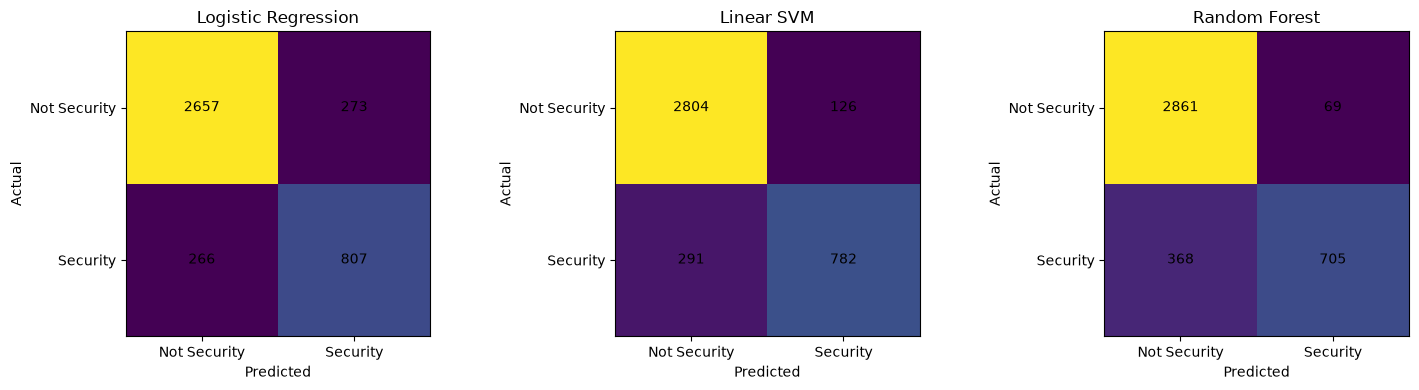

In [24]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for ax, (model_name, cm) in zip(
    axes,
    confusion_matrices.items()
):

    ax.imshow(cm)

    ax.set_title(model_name)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Not Security", "Security"])
    ax.set_yticklabels(["Not Security", "Security"])

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

plt.tight_layout()
plt.show()

In [25]:
OUTPUT_DIR = "../../data/pr_review_traces/processed/comment_patch_ml_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

for model_name, cm in confusion_matrices.items():

    safe_model_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    cm_df = pd.DataFrame(
        cm,
        index=["actual_0", "actual_1"],
        columns=["predicted_0", "predicted_1"]
    )

    cm_path = os.path.join(
        OUTPUT_DIR,
        f"confusion_comment_patch_{safe_model_name}.csv"
    )

    cm_df.to_csv(cm_path)

    print("Saved:", cm_path)

Saved: ../../data/pr_review_traces/processed/comment_patch_ml_results/confusion_comment_patch_logistic_regression.csv
Saved: ../../data/pr_review_traces/processed/comment_patch_ml_results/confusion_comment_patch_linear_svm.csv
Saved: ../../data/pr_review_traces/processed/comment_patch_ml_results/confusion_comment_patch_random_forest.csv


In [26]:
error_counts = []

for model_name in models:

    model_oof = oof_df[
        oof_df["model"] == model_name
    ]

    false_positives = (
        (model_oof["security_label"] == 0)
        & (model_oof["prediction"] == 1)
    ).sum()

    false_negatives = (
        (model_oof["security_label"] == 1)
        & (model_oof["prediction"] == 0)
    ).sum()

    error_counts.append({
        "model": model_name,
        "False Positive": false_positives,
        "False Negative": false_negatives
    })

error_counts_df = pd.DataFrame(error_counts)

error_counts_df

,model,False Positive,False Negative
0,Logistic Regression,273,266
1,Linear SVM,126,291
2,Random Forest,69,368


In [27]:
for model_name in models:

    model_oof = oof_df[
        oof_df["model"] == model_name
    ]

    fp = model_oof[
        (model_oof["security_label"] == 0)
        & (model_oof["prediction"] == 1)
    ]

    fn = model_oof[
        (model_oof["security_label"] == 1)
        & (model_oof["prediction"] == 0)
    ]

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    print("False positives:", len(fp))
    print("False negatives:", len(fn))


Logistic Regression
False positives: 273
False negatives: 266

Linear SVM
False positives: 126
False negatives: 291

Random Forest
False positives: 69
False negatives: 368


In [28]:
false_positive_cases = oof_df[
    oof_df["security_label"].eq(0)
    & oof_df["prediction"].eq(1)
].copy()

false_positive_cases[
    [
        "model",
        "repo_name",
        "pr_number",
        "comment_id",
        "review_comment",
        "diff_hunk",
        "file_path",
        "security_label",
        "prediction"
    ]
].head(20)

,model,repo_name,pr_number,comment_id,review_comment,diff_hunk,file_path,security_label,prediction
8,Logistic Regression,langchain4j/langchain4j-community,59,2021042948,done,"@@ -0,0 +1,39 @@\n+package dev.langchain4j.dat...",document-parsers/langchain4j-document-parser-l...,0,1
10,Logistic Regression,goauthentik/authentik,13586,2014506012,```suggestion\r\n#\r\n# You may edit the gener...,"@@ -1,5 +1,17 @@\n-# update website/docs/insta...",authentik/lib/default.yml,0,1
13,Logistic Regression,naukmagymdb/gym,46,2064044399,"a сорі, я забув що у нас такі є вимоги, так то...","@@ -0,0 +1,105 @@\n+import { ConflictException...",packages/backend/src/products/products.service.ts,0,1
18,Logistic Regression,statsig-io/docs,2854,2036022980,"The ""Notes"" and ""References"" sections currentl...","@@ -0,0 +1,99 @@\n+---\n+title: Geotests\n+sid...",docs/statsig-warehouse-native/geotests/introdu...,0,1
23,Logistic Regression,elastic/elasticsearch,126091,2041283443,"Yep, naming is hard :) I'll update.","@@ -0,0 +1,175 @@\n+/*\n+ * Copyright Elastics...",server/src/main/java/org/elasticsearch/cluster...,0,1
25,Logistic Regression,ImperialCollegeLondon/imperial_coldfront_plugin,216,2079351617,Well spotted!,"@@ -631,3 +641,50 @@ def task_stat_view(reques...",imperial_coldfront_plugin/views.py,0,1
30,Logistic Regression,cognitedata/dotnet-simulator-utils,239,1975028429,"agreed, removed this from here","@@ -0,0 +1,226 @@\n+using System;\n+using Syst...",Cognite.Simulator.Utils/LicenseController.cs,0,1
48,Logistic Regression,FinOps-Open-Cost-and-Usage-Spec/FOCUS_Spec,830,2003393218,Capitalization on `co`,"@@ -0,0 +1,89 @@\n+# SaaS Spend Agreements\n+\...",specification/appendix/saas_examples/spend_agr...,0,1
76,Logistic Regression,debezium/debezium.github.io,1133,2100610214,```suggestion\r\nYou also use https://github.c...,"@@ -0,0 +1,438 @@\n+---\n+layout: post\n+title...",_posts/2025-05-22-debezium-as-part-of-your-ai-...,0,1
131,Logistic Regression,bevyengine/bevy,18782,2038539220,and also a bunch of `std` usage in this mod ne...,"@@ -0,0 +1,341 @@\n+use alloc::{\n+ boxed::...",crates/bevy_log/src/plugin.rs,0,1


In [29]:
false_negative_cases = oof_df[
    oof_df["security_label"].eq(1)
    & oof_df["prediction"].eq(0)
].copy()

false_negative_cases[
    [
        "model",
        "repo_name",
        "pr_number",
        "comment_id",
        "review_comment",
        "diff_hunk",
        "file_path",
        "security_label",
        "prediction"
    ]
].head(20)

,model,repo_name,pr_number,comment_id,review_comment,diff_hunk,file_path,security_label,prediction
1,Logistic Regression,vinteumorg/Floresta,402,1987570671,"i agree with davidson, a `uv run tests/run_tes...","@@ -258,53 +258,64 @@ cargo test --release\n \...",README.md,1,0
5,Logistic Regression,Argus-Labs/world-cli,143,2056914921,logic: processRepoToken no longer handles 'pub...,"@@ -440,25 +441,17 @@ func (p *project) prompt...",cmd/world/forge/project.go,1,0
9,Logistic Regression,hashintel/hash,6880,2031894558,unused import: `HashSet`\n\n[Show more details...,"@@ -103,14 +142,18 @@\n #[expect(clippy::panic...",libs/@local/graph/authorization/src/policies/a...,1,0
16,Logistic Regression,1024pix/pix,12268,2084893227,Les fichiers sont plutôt nommés en Kebab-case ...,"@@ -22,6 +21,7 @@ import { certificationSessio...",api/server.js,1,0
17,Logistic Regression,causify-ai/helpers,374,1999651519,Are 39-46 still needed then?\r\n\r\nLet's try ...,"@@ -48,8 +50,9 @@ jobs:\n id: login-ec...",.github/workflows/fast_tests.yml,1,0
22,Logistic Regression,opendatahub-io/opendatahub-tests,175,1999354657,`if _upgrade_deployment_modes` -> need to retu...,"@@ -102,19 +123,45 @@ def pytest_collection_mo...",conftest.py,1,0
34,Logistic Regression,bcgov/lear,3523,2116877801,Thanks! Was just running into this starting to...,"@@ -24,3 +23,14 @@ git+https://github.com/bcgo...",queue_services/entity-digital-credentials/requ...,1,0
50,Logistic Regression,shopinvader/odoo-shopinvader,1574,1875832296,```suggestion\r\n address_type: Address...,"@@ -120,49 +126,121 @@ def get_delivery_addres...",shopinvader_api_address/routers/address_servic...,1,0
53,Logistic Regression,elastic/elasticsearch,124144,1982115326,We don't need to be recreating the object on e...,"@@ -38,16 +56,13 @@ public String inferenceEnt...",x-pack/plugin/inference/src/main/java/org/elas...,1,0
56,Logistic Regression,artsy/eigen,11884,2038266387,"This change removes the ""plumbing"" that allowe...","@@ -115,39 +105,6 @@ export const Swiper = for...",src/app/Scenes/InfiniteDiscovery/Components/Sw...,1,0


In [30]:
error_cases = oof_df[
    (
        (oof_df["security_label"] == 0)
        & (oof_df["prediction"] == 1)
    )
    |
    (
        (oof_df["security_label"] == 1)
        & (oof_df["prediction"] == 0)
    )
].copy()

error_cases_path = os.path.join(
    OUTPUT_DIR,
    "comment_patch_false_positive_false_negative_cases.csv"
)

error_cases.to_csv(
    error_cases_path,
    index=False
)

print("Saved:", error_cases_path)

Saved: ../../data/pr_review_traces/processed/comment_patch_ml_results/comment_patch_false_positive_false_negative_cases.csv


In [31]:
for model_name in models:

    model_oof = oof_df[
        oof_df["model"] == model_name
    ]

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)

    print(
        classification_report(
            model_oof["security_label"],
            model_oof["prediction"],
            target_names=[
                "Not Security",
                "Security"
            ],
            digits=4,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

Not Security     0.9090    0.9068    0.9079      2930
    Security     0.7472    0.7521    0.7497      1073

    accuracy                         0.8654      4003
   macro avg     0.8281    0.8295    0.8288      4003
weighted avg     0.8656    0.8654    0.8655      4003


Linear SVM
              precision    recall  f1-score   support

Not Security     0.9060    0.9570    0.9308      2930
    Security     0.8612    0.7288    0.7895      1073

    accuracy                         0.8958      4003
   macro avg     0.8836    0.8429    0.8601      4003
weighted avg     0.8940    0.8958    0.8929      4003


Random Forest
              precision    recall  f1-score   support

Not Security     0.8860    0.9765    0.9290      2930
    Security     0.9109    0.6570    0.7634      1073

    accuracy                         0.8908      4003
   macro avg     0.8984    0.8167    0.8462      4003
weighted avg     0.8927   

In [32]:
fold_metrics_path = os.path.join(
    OUTPUT_DIR,
    "comment_patch_fold_metrics.csv"
)

cv_summary_path = os.path.join(
    OUTPUT_DIR,
    "comment_patch_cv_summary.csv"
)

oof_predictions_path = os.path.join(
    OUTPUT_DIR,
    "comment_patch_oof_predictions.csv"
)

fold_metrics.to_csv(
    fold_metrics_path,
    index=False
)

cv_summary.to_csv(
    cv_summary_path
)

oof_df.to_csv(
    oof_predictions_path,
    index=False
)

print("Saved:")
print("-", fold_metrics_path)
print("-", cv_summary_path)
print("-", oof_predictions_path)

Saved:
- ../../data/pr_review_traces/processed/comment_patch_ml_results/comment_patch_fold_metrics.csv
- ../../data/pr_review_traces/processed/comment_patch_ml_results/comment_patch_cv_summary.csv
- ../../data/pr_review_traces/processed/comment_patch_ml_results/comment_patch_oof_predictions.csv


In [33]:
summary_table = cv_summary.copy()

summary_table.columns = [
    f"{metric}_{stat}"
    for metric, stat in summary_table.columns
]

summary_table = summary_table.round(4)

summary_table

,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
model,,,,,,,,,,
Linear SVM,0.8958,0.0133,0.8429,0.0213,0.8617,0.0287,0.7288,0.0414,0.7892,0.0297
Logistic Regression,0.8654,0.0159,0.8295,0.0245,0.7482,0.0317,0.7521,0.0504,0.7493,0.0320
Random Forest,0.8908,0.0104,0.8167,0.0228,0.9117,0.0164,0.6570,0.0501,0.7625,0.0307
